In [1]:
# Copyright 2026 Syed Basim Ali
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:_.2f}'.format
pd.set_option("display.expand_frame_repr", False)

In [3]:
%run get_recent_results.py

Skipped copying, destination is up to date.
Skipped copying, destination is up to date.
Skipped copying, destination is up to date.
Skipped copying, destination is up to date.


In [4]:
plot_dir = "plots/bench_raw_buf"
os.makedirs(plot_dir, exist_ok=True)

In [5]:
df_64 = pd.read_csv("bench_raw_buf_float64.csv")
df_32 = pd.read_csv("bench_raw_buf_float32.csv")

df_dict = {
    "df_64": df_64,
    "df_32": df_32,
}

In [6]:
# for key in df_dict:
#     df_dict[key] = df_dict[key][df_dict[key]["MAX_LEN"] == 131_072].reset_index(drop=True)

In [7]:
for name, df in df_dict.items():
    print(f"\n{name}\n{df}")


df_64
                      VARIANT    TIME  BLOCK_SIZE  MAX_LEN  NUM_RUNS
0    RefPythonNumPyCircBuffer    2705           8        8      5163
1         OverwriteCircBuffer     229           8        8      5163
2    RefPythonNumPyCircBuffer    2941           8       16      5163
3         OverwriteCircBuffer     235           8       16      5163
4    RefPythonNumPyCircBuffer    2494           8       32      5163
..                        ...     ...         ...      ...       ...
301       OverwriteCircBuffer   95561      262144   262144      5163
302  RefPythonNumPyCircBuffer   96248      262144   524288      5163
303       OverwriteCircBuffer   96342      262144   524288      5163
304  RefPythonNumPyCircBuffer  203674      524288   524288      5163
305       OverwriteCircBuffer  199103      524288   524288      5163

[306 rows x 5 columns]

df_32
                      VARIANT    TIME  BLOCK_SIZE  MAX_LEN  NUM_RUNS
0    RefPythonNumPyCircBuffer    2587           8        8     10

In [8]:
for name, df in df_dict.items():
    print(f"\n{name}\n{df.describe()}")


df_64
            TIME  BLOCK_SIZE    MAX_LEN  NUM_RUNS
count     306.00      306.00     306.00    306.00
mean    5_979.01   13_705.88 109_655.06  5_163.00
std    20_308.61   54_917.56 167_306.34      0.00
min       220.00        8.00       8.00  5_163.00
25%       349.00       32.00   2_048.00  5_163.00
50%     2_585.00      256.00  16_384.00  5_163.00
75%     2_955.75    2_048.00 131_072.00  5_163.00
max   203_674.00  524_288.00 524_288.00  5_163.00

df_32
            TIME  BLOCK_SIZE    MAX_LEN  NUM_RUNS
count     306.00      306.00     306.00    306.00
mean    3_541.04   13_705.88 109_655.06 10_329.00
std     9_948.12   54_917.56 167_306.34      0.00
min       216.00        8.00       8.00 10_329.00
25%       314.25       32.00   2_048.00 10_329.00
50%     2_564.50      256.00  16_384.00 10_329.00
75%     2_798.00    2_048.00 131_072.00 10_329.00
max   105_055.00  524_288.00 524_288.00 10_329.00


In [9]:
# df["THROUGHPUT"] = (df["BLOCK_SIZE"] * 4) / (df["TIME"])
# df_temp = df[df["VARIANT"] == 'OverwriteCircBuffer']
# print("Bottom 5:")
# print(df_temp.sort_values('THROUGHPUT', ascending=True).head(5))
# print("\nTop 5:")
# print(df_temp.sort_values('THROUGHPUT', ascending=False).head(5))


df_64


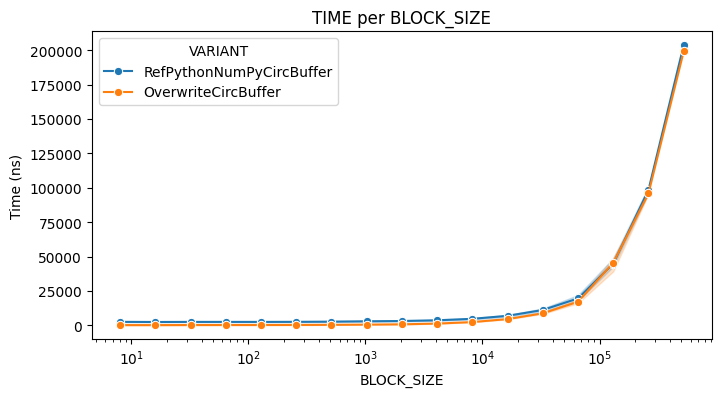


df_32


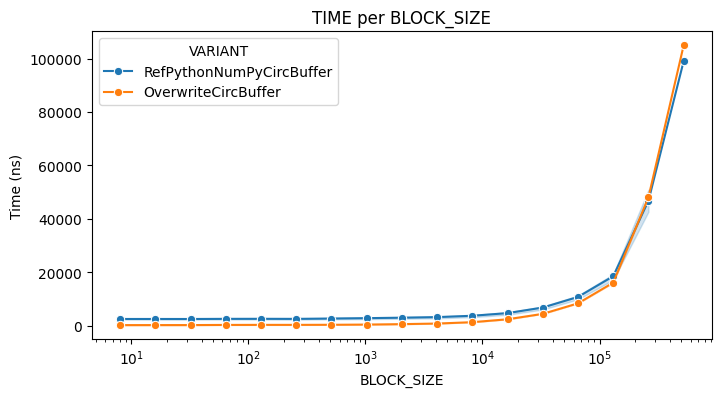

In [10]:
for name, df in df_dict.items():
    print(f"\n{name}")
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=df, x="BLOCK_SIZE", y="TIME", hue="VARIANT", marker="o")
    plt.xlabel("BLOCK_SIZE")
    plt.ylabel("Time (ns)")
    plt.title("TIME per BLOCK_SIZE")
    plt.xscale("log")
    plt.show()
    plt.close()


df_64


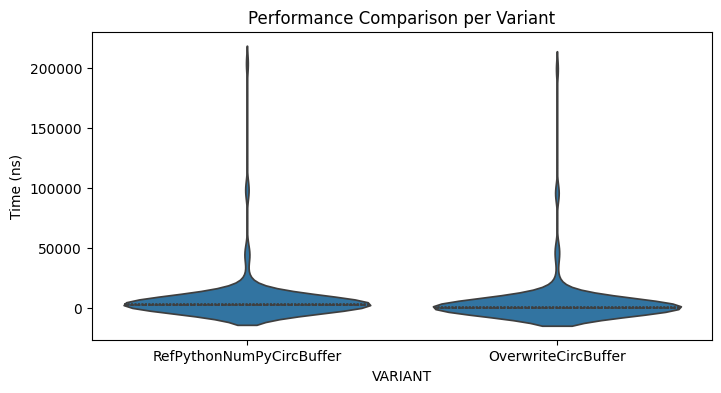


df_32


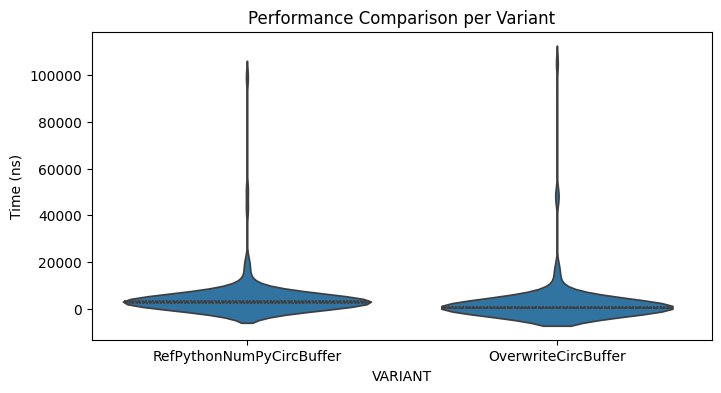

In [11]:
for name, df in df_dict.items():
    print(f"\n{name}")
    plt.figure(figsize=(8,4))
    sns.violinplot(data=df, x='VARIANT', y='TIME', inner="quartile")
    plt.ylabel("Time (ns)")
    plt.title("Performance Comparison per Variant")
    plt.show()
    plt.close()



df_64

--- BLOCK_SIZE ---

min rel = 0.987 at BLOCK_SIZE = 131_072
max rel = 10.301 at BLOCK_SIZE = 8
First diminishing performance below 1.05x at BLOCK_SIZE ≈ 99_169, rel = 1.049


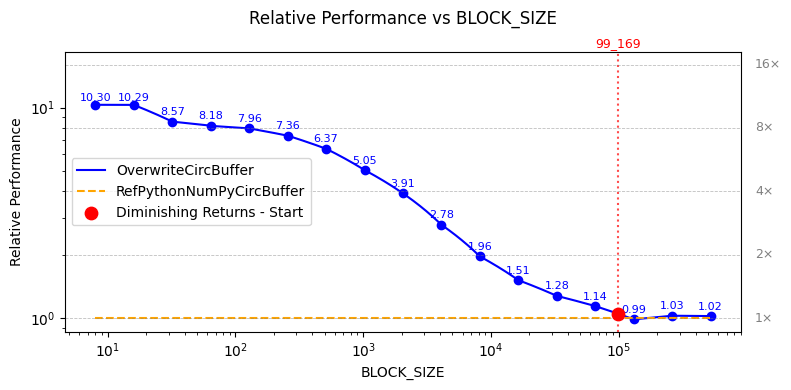



df_32

--- BLOCK_SIZE ---

min rel = 0.944 at BLOCK_SIZE = 524_288
max rel = 11.285 at BLOCK_SIZE = 8
First diminishing performance below 1.05x at BLOCK_SIZE ≈ 195_197, rel = 1.048


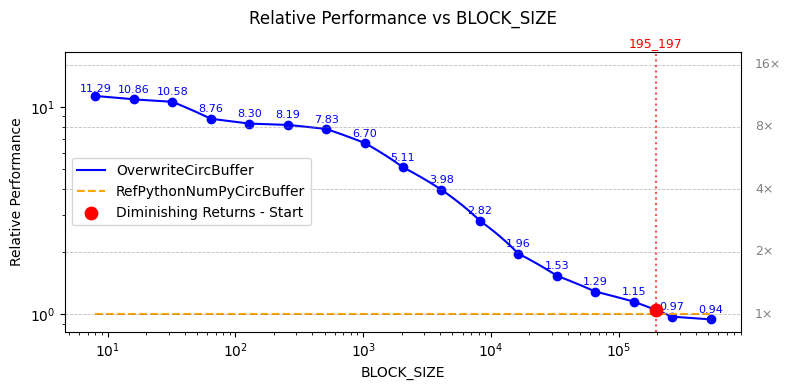

In [12]:
METRICS = [
    "BLOCK_SIZE",
]

for name, df in df_dict.items():
    print(f"\n\n{name}")

    df_pivot = df.pivot(
        index=["BLOCK_SIZE", "MAX_LEN", "NUM_RUNS"],
        columns="VARIANT",
        values="TIME",
    ).reset_index()

    for metric in METRICS:
        df_grouped = df_pivot.groupby(metric).mean().reset_index()
        df_grouped = df_grouped.sort_values(metric)
        df_grouped["rel"] = (
            df_grouped["RefPythonNumPyCircBuffer"] / df_grouped["OverwriteCircBuffer"]
        )

        min_idx = df_grouped["rel"].idxmin()
        max_idx = df_grouped["rel"].idxmax()

        min_val = df_grouped.loc[min_idx, "rel"]
        max_val = df_grouped.loc[max_idx, "rel"]

        min_x = df_grouped.loc[min_idx, metric]
        max_x = df_grouped.loc[max_idx, metric]

        print(f"\n--- {metric} ---\n")
        print(f"min rel = {min_val:.3f} at {metric} = {min_x:_}")
        print(f"max rel = {max_val:.3f} at {metric} = {max_x:_}")

        x = df_grouped[metric].values
        y_numpy = df_grouped["rel"].values

        x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 1000)
        y_numpy_smooth = np.interp(np.log10(x_smooth), np.log10(x), y_numpy)

        # Find first diminishing performance point < 1.05, left to right
        first_diminish_idx = np.where(y_numpy_smooth < 1.05)[0]
        if first_diminish_idx.size > 0:
            idx = first_diminish_idx[0]
            x_diminish = x_smooth[idx]
            y_diminish = y_numpy_smooth[idx]
            print(
                f"First diminishing performance below 1.05x at {metric} ≈ {round(x_diminish):_}, rel = {y_diminish:.3f}"
            )
        else:
            x_diminish = None
            print(f"Performance never drops below 1.05 for {metric}")

        fig, ax = plt.subplots(figsize=(8, 4))

        ax.plot(x_smooth, y_numpy_smooth, label="OverwriteCircBuffer", color="blue")
        ax.scatter(x, y_numpy, color="blue")
        ymax = ax.get_ylim()[1]
        for xi, yi in zip(x, y_numpy):
            y_text = min(yi * 1.05, ymax * 0.98)
            ax.text(
                xi,
                y_text,
                f"{yi:.2f}",
                fontsize=8,
                ha="center",
                va="bottom",
                color="blue",
            )

        ax.plot(
            x_smooth,
            np.ones_like(x_smooth),
            label="RefPythonNumPyCircBuffer",
            color="orange",
            linestyle="--",
        )

        if x_diminish is not None:
            ax.scatter(
                x_diminish,
                y_diminish,
                color="red",
                s=80,
                zorder=5,
                label="Diminishing Returns - Start",
            )
            ax.axvline(x_diminish, color='red', linestyle=':', alpha=0.7)
            ax.text(x_diminish, y_diminish*0.97, f"{round(x_diminish):_}", color='red', fontsize=9,
                    ha='center', transform=ax.get_xaxis_transform())

        ref_lines = [1, 2, 4, 8, 16]
        for r in ref_lines:
            ax.axhline(
                r, color="gray", linestyle="--", linewidth=0.6, alpha=0.5
            )
            ax.text(
                1.02,
                r,
                f"{r}×",
                va="center",
                ha="left",
                color="gray",
                fontsize=9,
                transform=ax.get_yaxis_transform(),
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(metric)
        ax.set_ylabel("Relative Performance")
        ax.set_title(f"Relative Performance vs {metric}", pad=20)
        ax.legend()
        plt.tight_layout()
        plt.show()

        filename = os.path.join(plot_dir, f"{name}_{metric}.png")
        fig.savefig(filename, dpi=300)
        plt.close()